In [ ]:
#subset by longitude to look for local effects
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import dask.array as da
import dask.dataframe as dd
import xarray as xr
from xnemogcm import open_domain_cfg, get_metrics
import xgcm
import cartopy.crs as ccrs
import cmocean
import numpy as np
from scipy.stats import linregress
import datetime
import pandas as pd
import plots_spatial as pltspat
# Add SouthernDemons library to PATH
sys.path.append(os.path.abspath("../lib/"))
from teos_ten import teos_sigma0
import datesandtime

# Subdomain information (As inputted into TRACMASS, note non-pythonic indexing)
imindom = 1
imaxdom = 1440
jmindom = 1
jmaxdom = 400
kmindom = 1
kmaxdom = 75

# Location of the parquet data
data_dir = os.path.abspath("/gws/nopw/j04/bas_pog/evrkin74/Forwards_Ventilation")

ndense_path = os.path.abspath("/gws/nopw/j04/bas_pog/astyles/SouthernDemons/neutraldensity/output/ORCA025_Dec1982/*.nc" )
# Location of masks and grid information for the model
grid_path = os.path.abspath("/gws/nopw/j04/bas_pog/astyles/ORCA025_fwd/topo" )
grid_files = ['mask.nc','mesh_hgr.nc','mesh_zgr.nc']

cal_months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Use dask to load the tabulated data lazily 
#df_ini = dd.read_parquet(out_dir + f"/df_ini.combined.parquet")
#df_out = dd.read_parquet(out_dir + f"/df_out.combined.parquet")
df_vent = dd.read_parquet(data_dir + f"/df_vent.parquet")
ds_domain = open_domain_cfg( datadir=grid_path, files = grid_files )
col = ['red','green','yellow']


In [1]:
print('a')

a


In [4]:
df_vent.dtypes


ntraj_o            int64
x_o              float64
y_o              float64
z_o              float64
subvol_o         float64
time_o           float64
boxface_o          int64
temp_o           float64
sal_o            float64
density_o        float64
density10_o      float64
ntrajc             int64
ntraj_i            int64
x_i              float64
y_i              float64
z_i              float64
subvol_i         float64
time_i           float64
boxface_i          int64
temp_i           float64
sal_i            float64
density_i        float64
density10_i      float64
year_i             int64
month_i            int64
day_i              int64
dayofyear_i        int64
year_o             int64
month_o            int64
day_o              int64
dayofyear_o        int64
binnedx_i          int64
binnedy_i          int64
binnedz_i          int64
binnedx_o          int64
binnedy_o          int64
binnedz_o          int64
nd_bin_ini         int64
sf_zint          float64
bathy_depth_i    float64


In [3]:
len(df_ini)

482615340

In [30]:
def plot_o(ds_domain, vol_xy, y, ax,vmax=1e3,log=True, cmp =cmocean.cm.thermal ): 
    #print((vol_xy.head(5)))
    da_vol_xy = vol_xy.to_xarray()[y]
    #print(da_vol_xy.head(4))
    # Define coordinates x_c and y_c which are the Pythonic indices rather than the TRACMASS indices. This ensures agreement with the coordinates for ds_domain
  
    da_vol_xy = da_vol_xy.assign_coords( {'x_c':da_vol_xy.binnedx_o-1 , 'y_c':da_vol_xy.binnedy_o - 1} ) 
    da_vol_xy = da_vol_xy.swap_dims({'binnedx_o':'x_c', 'binnedy_o':'y_c'})
    
    # Reorder axes to agree with ds_subdomain
    da_vol_xy = da_vol_xy.transpose("y_c","x_c",...)
    
    
    # Align the coordinates of the grid file with the subdomain in da_vol_xy
    ds_domain_allign, da_vol_xy = xr.align( ds_domain, da_vol_xy )

    lat = ds_domain_allign.gphit
    lon = ds_domain_allign.glamt
    
    
    
    #vmax = vnorm.max().compute()

    
    vmin=vmax*1e-3    
    if log == True:
        lognorm = matplotlib.colors.LogNorm(vmax = vmax, vmin = vmax /1e3 )
        cax = ax.pcolormesh( lon, lat, da_vol_xy, transform=ccrs.PlateCarree(), cmap=cmp, norm=lognorm )
    else:
        cax = ax.pcolormesh( lon, lat,  da_vol_xy, transform=ccrs.PlateCarree(), cmap=cmp)
    ax.coastlines()
    fig.colorbar(cax)
    return fig ,ax

In [31]:
def plot_i(ds_domain, vol_xy, y,ax,vmax=1e3,log=True, cmp =cmocean.cm.thermal ): 
    #print((vol_xy.head(5)))
    da_vol_xy = vol_xy.to_xarray()[y]
    #print(da_vol_xy.head(4))
    # Define coordinates x_c and y_c which are the Pythonic indices rather than the TRACMASS indices. This ensures agreement with the coordinates for ds_domain
  
    da_vol_xy = da_vol_xy.assign_coords( {'x_c':da_vol_xy.binnedx_i-1 , 'y_c':da_vol_xy.binnedy_i - 1} ) 
    da_vol_xy = da_vol_xy.swap_dims({'binnedx_i':'x_c', 'binnedy_i':'y_c'})
    
    # Reorder axes to agree with ds_subdomain
    da_vol_xy = da_vol_xy.transpose("y_c","x_c",...)
    
    
    # Align the coordinates of the grid file with the subdomain in da_vol_xy
    ds_domain_allign, da_vol_xy = xr.align( ds_domain, da_vol_xy )

    lat = ds_domain_allign.gphit
    lon = ds_domain_allign.glamt
    
    
    
    #vmax = vnorm.max().compute()

    
    vmin=vmax*1e-3    
    if log == True:
        lognorm = matplotlib.colors.LogNorm(vmax = vmax, vmin = vmax /1e3 )
        cax = ax.pcolormesh( lon, lat, da_vol_xy, transform=ccrs.PlateCarree(), cmap=cmp, norm=lognorm )
    else:
        cax = ax.pcolormesh( lon, lat,  da_vol_xy, transform=ccrs.PlateCarree(), cmap=cmp)
    ax.coastlines()
    fig.colorbar(cax)
    

In [47]:
def plot_seed(d_min,d_max,ax):   # plot seeding location & volume in density class
    df_densest = df_vent[(df_vent['ndense']>d_min) &(df_vent['ndense']<d_max) ][['binnedx_i','binnedy_i','ndense','year_o']]
    df_densest= df_densest[df_densest['year_o']>1983]
    df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
    count = df_group.count().compute()
    plot_i(ds_domain,count,'ndense',ax,log=False)

def plot_vent(d_min,d_max,ax): # plot ventilation location & volume in density class
    df_densest = df_vent[(df_vent['ndense']<d_max) &(df_vent['ndense']>d_min) ][['binnedx_o','binnedy_o','subvol_o','year_o']]
    df_densest= df_densest[df_densest['year_o']>1983]
    df_group = df_densest.groupby(['binnedx_o','binnedy_o'])
    count = df_group.sum('subvol_o').compute()
    plot_o(ds_domain,count,'subvol_o',ax,vmax=1e12)
def plot_depth(d_min,d_max,ax): # plot seeding depth & volume in density class, integrated around longitudes
    cmp =cmocean.cm.thermal 
    df_densest = df_vent[(df_vent['ndense']<d_max) &(df_vent['ndense']>d_min) ][['bin_depth_i','binnedy_i','subvol_i','year_o']]
    df_densest= df_densest[df_densest['year_o']>1983]
    df_group = df_densest.groupby(['binnedy_i','bin_depth_i'])
    count = df_group.sum('subvol_i').compute()
    count = count.reset_index()
    print(max(count.binnedy_i.values))
    count['lats'] = (ds_domain.e2t.gphit[:398,0])[count.binnedy_i.values-1]
# Pivot the DataFrame to get a 2D grid
    grid = count.pivot(index="bin_depth_i", columns="lats", values="subvol_i")
    #print(grid)
    # Extract the X, Y meshgrid from index and columns
    #print(max(count.binnedy_i))
    yy, zz = np.meshgrid(grid.columns, grid.index)
    
    # Extract the Z values (subvol_i) ensuring correct shape
    Z = grid.values
    
    ### now normalise by area of box
    xvals = ds_domain.e1t.values[:,0][:398]
    yvals = ds_domain.e2t.values[:,0][:398]
    zvals = ds_domain.e3t_1d.values
    zy_matrix = da.outer(zvals, yvals)  # Shape: (len(zvals), 398)


    vol = (zy_matrix * xvals)
   
    
    #print(da.shape(vol))
    shp = da.shape(Z)
    #print(shp)
    vol = vol[:shp[0],:shp[1]]
    cax = ax.pcolormesh(yy, zz, Z/vol, cmap=cmp)


    #now add max depth bathymetry
    bathy = ds_domain.mbathy.values[:398]
    #print(da.shape(bathy))
    real_depths = ds_domain.e3t_1d['gdept_1d']
    max_bathy = np.max(bathy, axis = 1)
    bathy_depths = real_depths[max_bathy]
    #print(len(bathy_depths))
    #print(1442,398)
    ax.plot(ds_domain.e2t.gphit[:398,0],bathy_depths, c = 'black',lw = 2)
    cbar=fig.colorbar(cax)
    cbar.set_label(r"Normalised Volume ($m^3$/$m^3$)", fontsize=14)


    for i,surf in enumerate([surf1,surf2,surf3]):
        zonal_avg = da.nanmean(surf.ns_depth.values[0][0], axis =1)
        ax.plot(ds_domain.e2t.gphit[:398,0],zonal_avg,c = col[i],lw = 1)
    #print(bathy_depths)
   
    #plt.colorbar(cax, ax=ax, label="Subvol_i")
    

In [50]:
## try to add neutral density surfaces to depth plot
surf1= xr.open_dataset('/gws/nopw/j04/bas_pog/astyles/SouthernDemons/neutraldensity/output/ORCA025_Dec1982/ns_Dec_depth2491_ipin950_jpin_275_itermax10.nc')
surf2= xr.open_dataset('/gws/nopw/j04/bas_pog/astyles/SouthernDemons/neutraldensity/output/ORCA025_Dec1982/ns_Dec_depth1914_ipin950_jpin_275_itermax10.nc')
surf3= xr.open_dataset('/gws/nopw/j04/bas_pog/astyles/SouthernDemons/neutraldensity/output/ORCA025_Dec1982/ns_Dec_depth3976_ipin950_jpin_275_itermax10.nc')



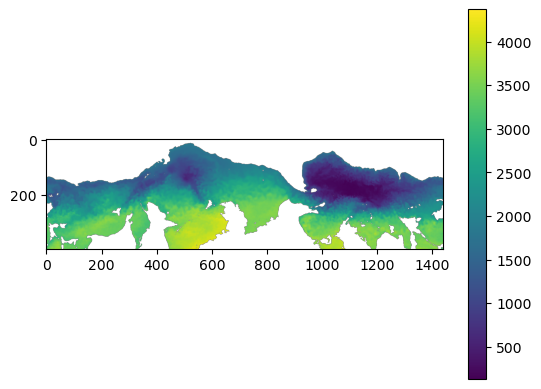

In [20]:

plt.imshow(surf.ns_depth.values[0][0])
plt.colorbar()

In [22]:
ds_domain.e2t.

<xarray.DataArray 'e2t' (y_c: 1021, x_c: 1442)> Size: 12MB
dask.array<getitem, shape=(1021, 1442), dtype=float64, chunksize=(128, 91), chunktype=numpy.ndarray>
Coordinates:
    glamt    (y_c, x_c) float32 6MB dask.array<chunksize=(128, 91), meta=np.ndarray>
    gphit    (y_c, x_c) float32 6MB dask.array<chunksize=(128, 91), meta=np.ndarray>
  * x_c      (x_c) int64 12kB 0 1 2 3 4 5 6 ... 1436 1437 1438 1439 1440 1441
  * y_c      (y_c) int64 8kB 0 1 2 3 4 5 6 ... 1015 1016 1017 1018 1019 1020
Attributes:
    units:    m

In [23]:
len(ds_domain.e2t.gphit[:398,0].values)

398

In [34]:
real_depths.values

array([5.05760017e-01, 1.55585530e+00, 2.66768175e+00, 3.85627974e+00,
       5.14036125e+00, 6.54303362e+00, 8.09251839e+00, 9.82275043e+00,
       1.17736795e+01, 1.39910380e+01, 1.65253215e+01, 1.94298028e+01,
       2.27576162e+01, 2.65583009e+01, 3.08745618e+01, 3.57402047e+01,
       4.11800247e+01, 4.72118941e+01, 5.38506372e+01, 6.11128402e+01,
       6.90216839e+01, 7.76111618e+01, 8.69294254e+01, 9.70413126e+01,
       1.08030281e+02, 1.20000001e+02, 1.33075822e+02, 1.47406245e+02,
       1.63164456e+02, 1.80549922e+02, 1.99789960e+02, 2.21141180e+02,
       2.44890622e+02, 2.71356387e+02, 3.00887515e+02, 3.33862834e+02,
       3.70688484e+02, 4.11793845e+02, 4.57625617e+02, 5.08639904e+02,
       5.65292274e+02, 6.28025970e+02, 6.97258648e+02, 7.73368259e+02,
       8.56678942e+02, 9.47447897e+02, 1.04585430e+03, 1.15199125e+03,
       1.26586142e+03, 1.38737698e+03, 1.51636363e+03, 1.65256845e+03,
       1.79567082e+03, 1.94529547e+03, 2.10102652e+03, 2.26242161e+03,
      

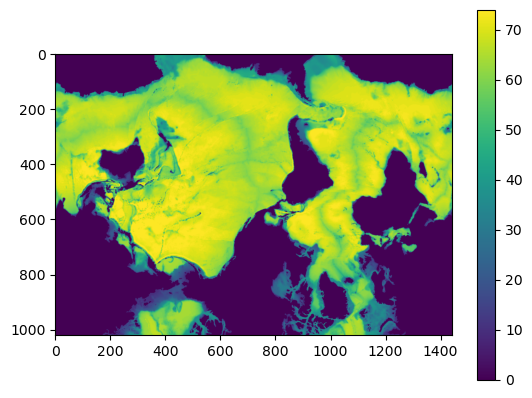

In [13]:
plt.imshow(ds_domain.mbathy.values)
plt.colorbar()

398


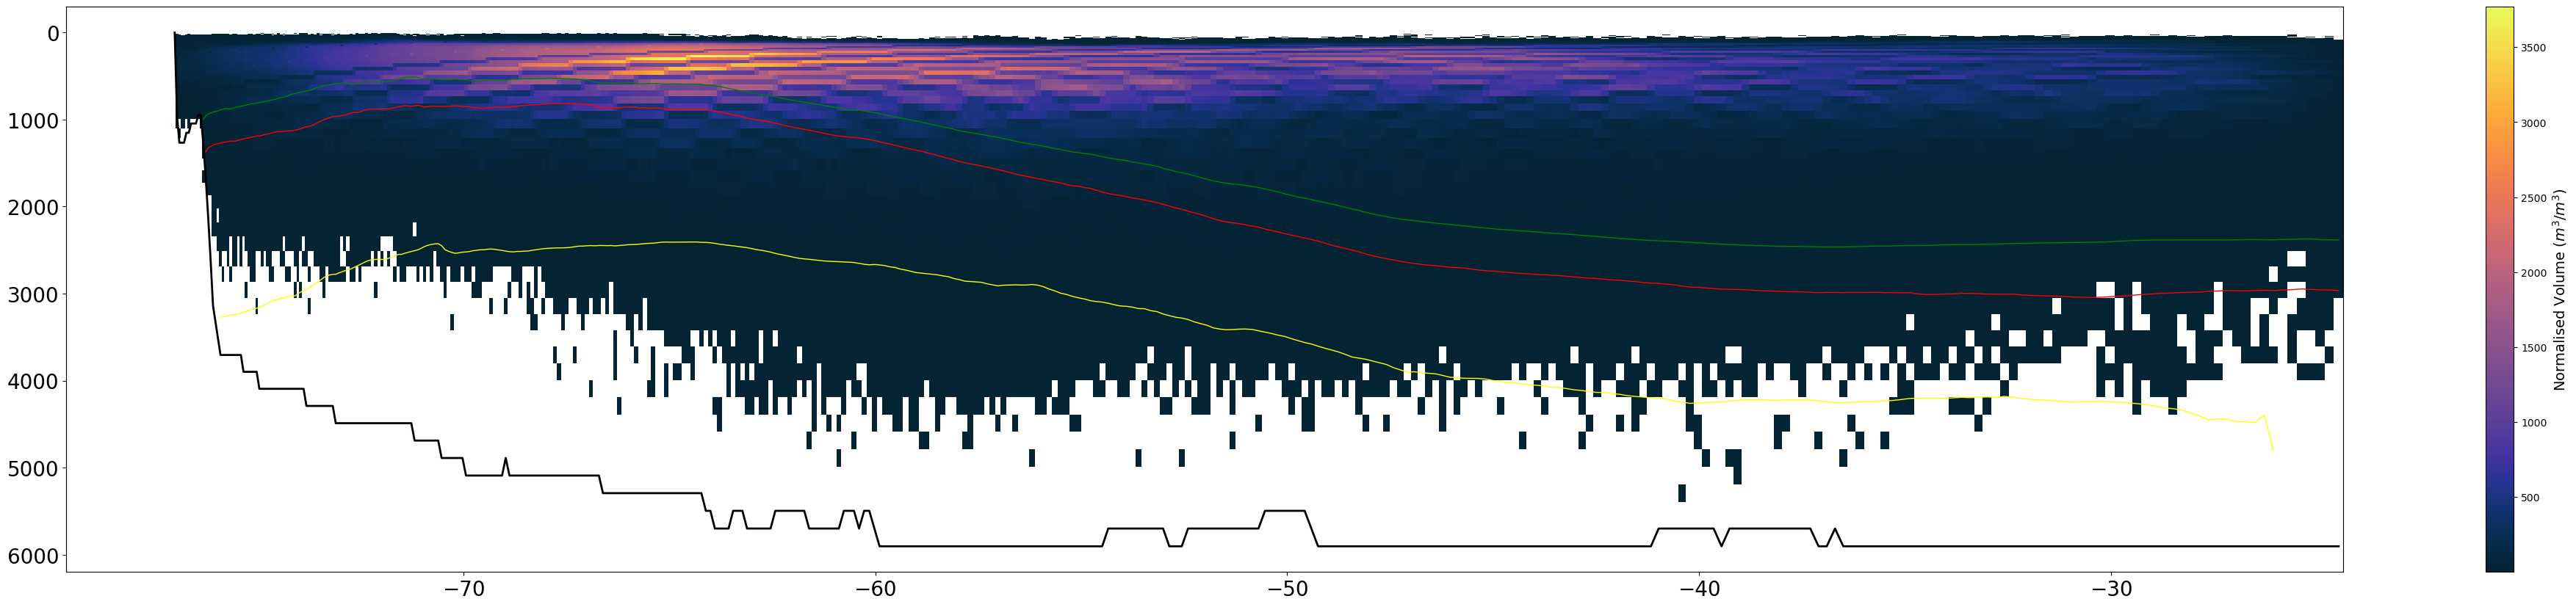

In [51]:
fig,ax = plt.subplots(1,1,sharex=True,sharey=True,figsize=(50,10))

plot_depth(1024,1029,ax)
ax.tick_params(axis='x', which='both', labelbottom=True)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.invert_yaxis()

398
385
398
398
398
398


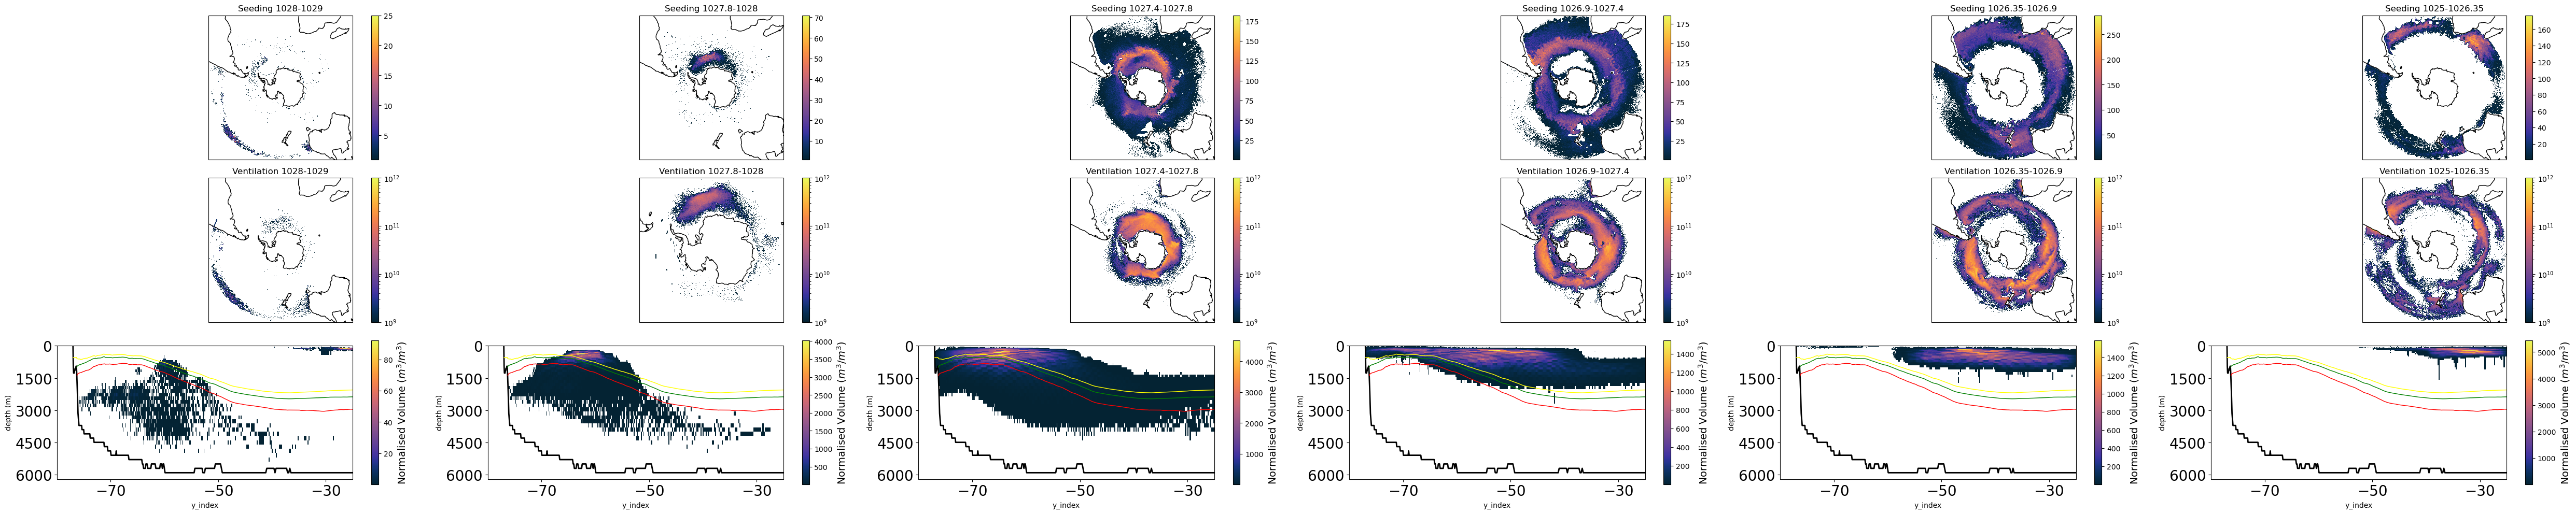

In [49]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

classes = [[1028, 1029], [1027.8, 1028], [1027.4, 1027.8], [1026.9, 1027.4], [1026.35, 1026.9], [1025, 1026.35]]
#classes = [[1025, 1025.6], [1025.6, 1026.35] ]
fig, ax = plt.subplots(3, len(classes), figsize=(50, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Ensure third row has the same x and y axis
x_min, x_max = -80,-25
y_min = None
y_max = None

for i, clas in enumerate(classes):
    # Plot data
    plot_seed(clas[0], clas[1], ax[0, i])
    ax[0, i].set_title(f'Seeding {clas[0]}-{clas[1]}')

    plot_vent(clas[0], clas[1], ax[1, i])
    ax[1, i].set_title(f'Ventilation {clas[0]}-{clas[1]}')

    plot_depth(clas[0], clas[1], ax[2, i])
    
    # Set x limits for all
    ax[2, i].set_xlim(x_min, x_max)

    # Invert y-axis and set same aspect ratio
    ax[2, i].invert_yaxis()
    ax[2, i].set_aspect(0.004)
    ax[2, i].set_xticks(np.linspace(-70, -30, 3))  # Adjust number of ticks as needed
    ax[2, i].set_yticks(np.linspace(0, 6000, 5))
    ax[2, i].tick_params(axis='both', which='both', labelsize=20)
    ax[2,i].set_xlabel('y_index')
    ax[2,i].set_ylabel('depth (m)')



    # Determine common y-limits
    y_min_i, y_max_i = ax[2, i].get_ylim()
    
    if y_min is None or y_min_i < y_min:
        y_min = y_min_i
    if y_max is None or y_max_i > y_max:
        y_max = y_max_i

# Apply same y limits to all plots in the third row
for i in range(len(classes)):
    ax[2, i].set_ylim(y_min, 0)

plt.tight_layout()
plt.savefig('../fig/Density_classes/combined_wdens.png', dpi=500, bbox_inches='tight')
plt.show()


In [ ]:
#### location of no neut density surfaces

In [11]:
df_none = df_vent[df_vent['ndense']==-1][['binnedx_i','binnedy_i','ndense','z_i']]
df_group = df_none.groupby(['binnedx_i','binnedy_i'])
count = df_group.count().compute()


(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

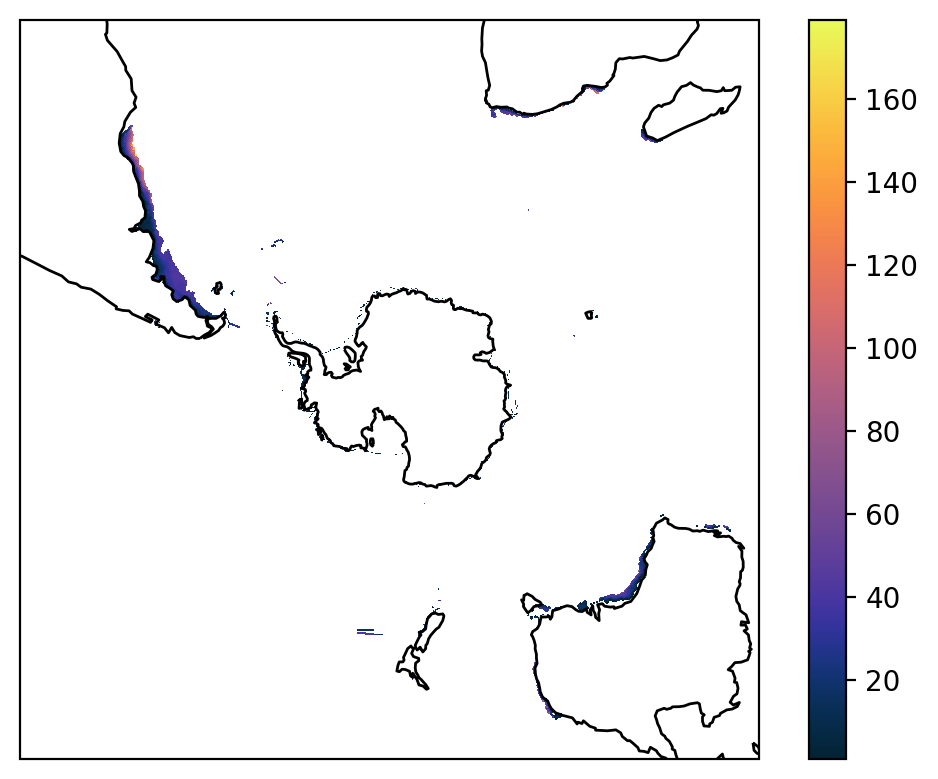

In [34]:
plot_i(ds_domain,count,'ndense',log=False)

In [142]:
########
#now isolate trajectories with  ndense >1028
df_densest = df_vent[df_vent['ndense']>1027.8][['binnedx_i','binnedy_i','ndense','z_i','year_o']]
df_densest= df_densest[df_densest['year_o']>1983]
df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
count = df_group.count().compute()


(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

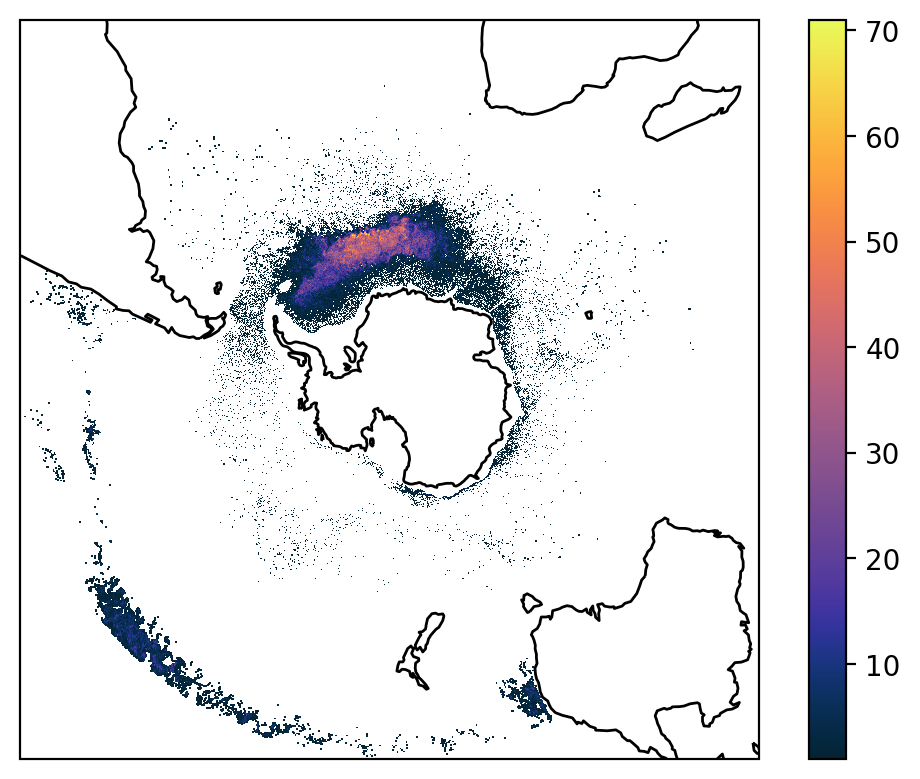

In [143]:
plot_i(ds_domain,count,'ndense',log=False)

In [47]:

df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
count = df_group.mean('z_i').compute()


(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

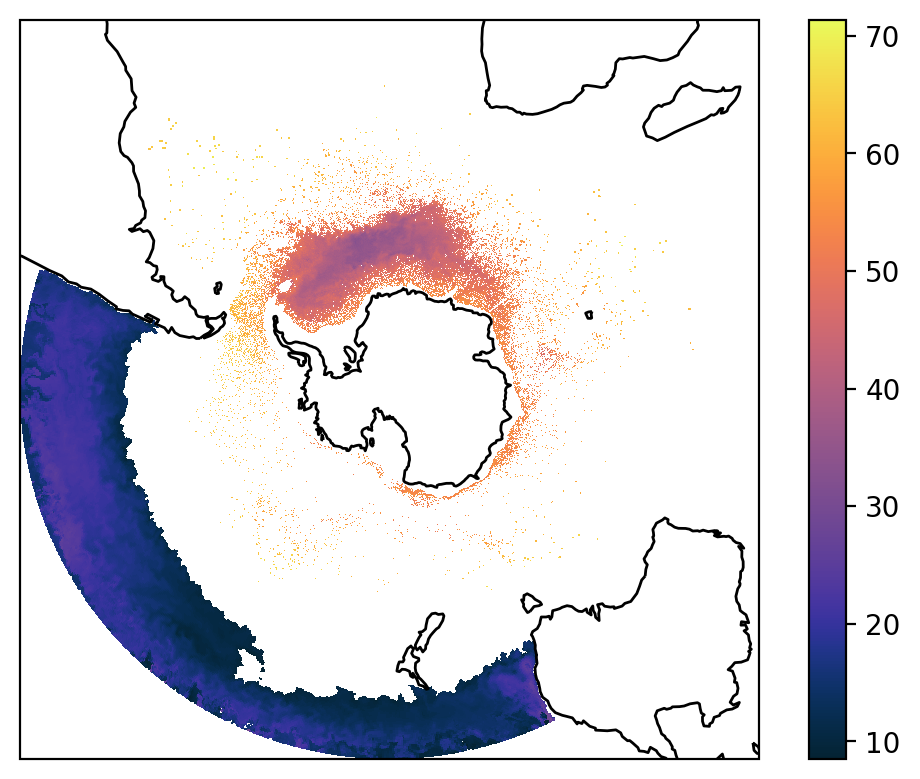

In [48]:
plot_i(ds_domain,count,'z_i',log=False)

In [50]:
df_densest = df_vent[df_vent['ndense']>1027.8][['binnedx_o','binnedy_o','subvol_o']]
df_group = df_densest.groupby(['binnedx_o','binnedy_o'])
count = df_group.sum('subvol_o').compute()

(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

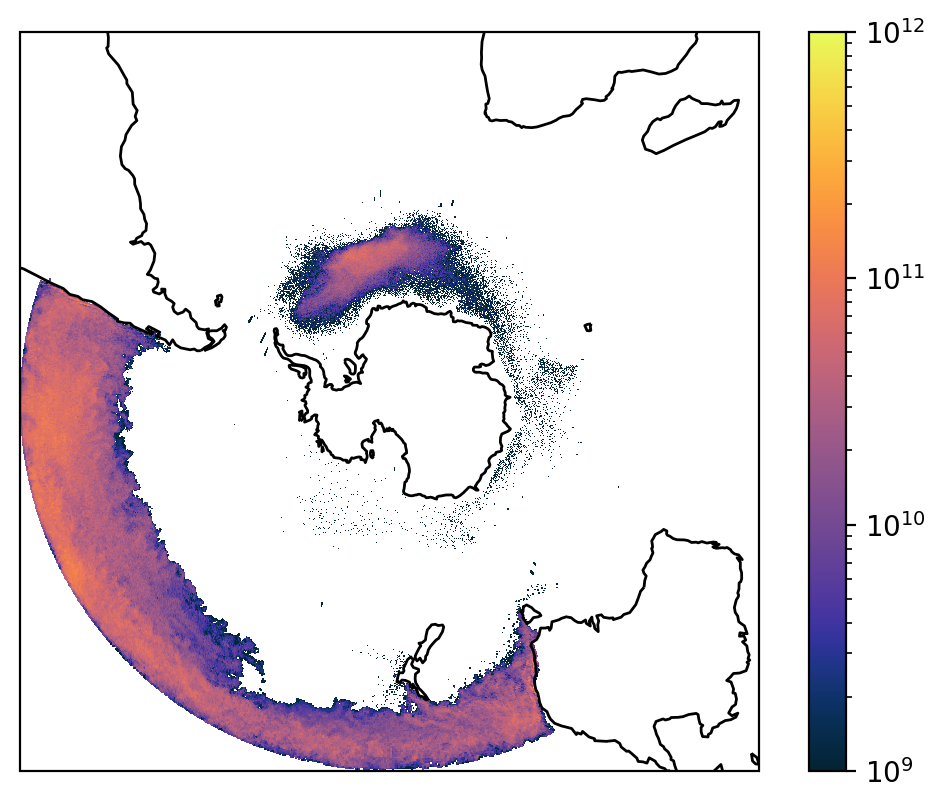

In [52]:
plot_o(ds_domain,count,'subvol_o',vmax=1e12)

In [155]:
#####try to isolate gyre
df_densest = df_vent[(df_vent['ndense']>1027.8) &(df_vent['ndense']<1028) ][['binnedx_i','binnedy_i','ndense','year_o']]
df_densest= df_densest[df_densest['year_o']>1983]
df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
count = df_group.count().compute()


(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

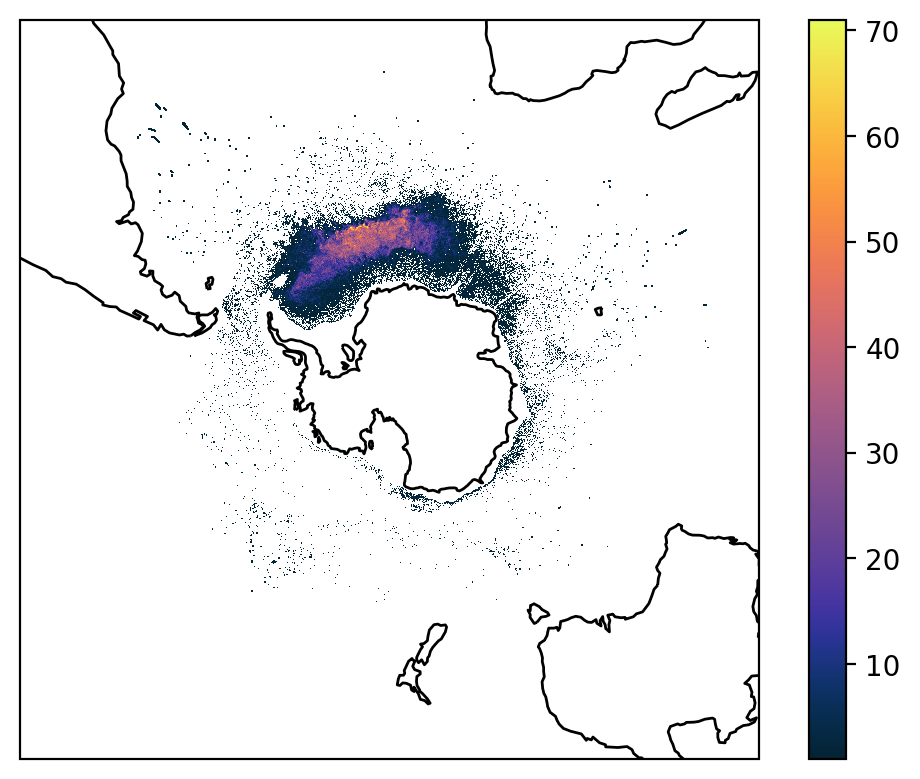

In [156]:
plot_i(ds_domain,count,'ndense',log=False)

In [158]:
df_densest = df_vent[(df_vent['ndense']>1027.8) &(df_vent['ndense']<1028) ][['binnedx_o','binnedy_o','subvol_o','year_o']]
df_densest= df_densest[df_densest['year_o']>1983]
df_group = df_densest.groupby(['binnedx_o','binnedy_o'])
count = df_group.sum('subvol_o').compute()

(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

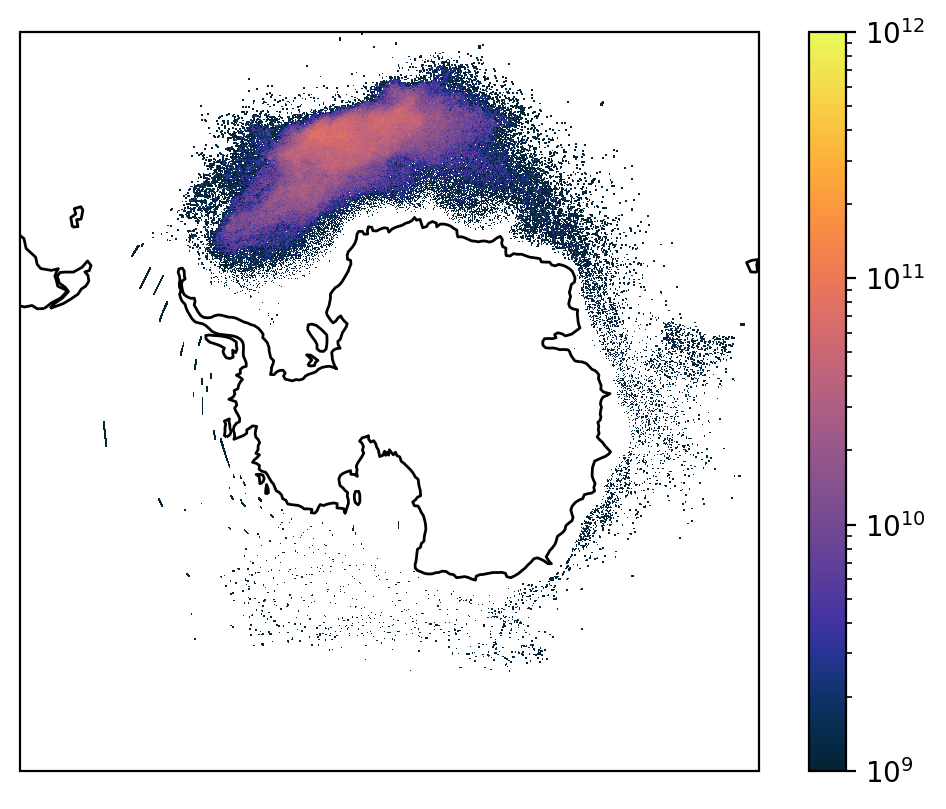

In [159]:
plot_o(ds_domain,count,'subvol_o',vmax=1e12)

In [ ]:
######

In [182]:
df_densest = df_vent[(df_vent['ndense']>1027.1) &(df_vent['ndense']<1027.2) ][['binnedx_i','binnedy_i','ndense','year_o']]
df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
count = df_group.count().compute()

(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

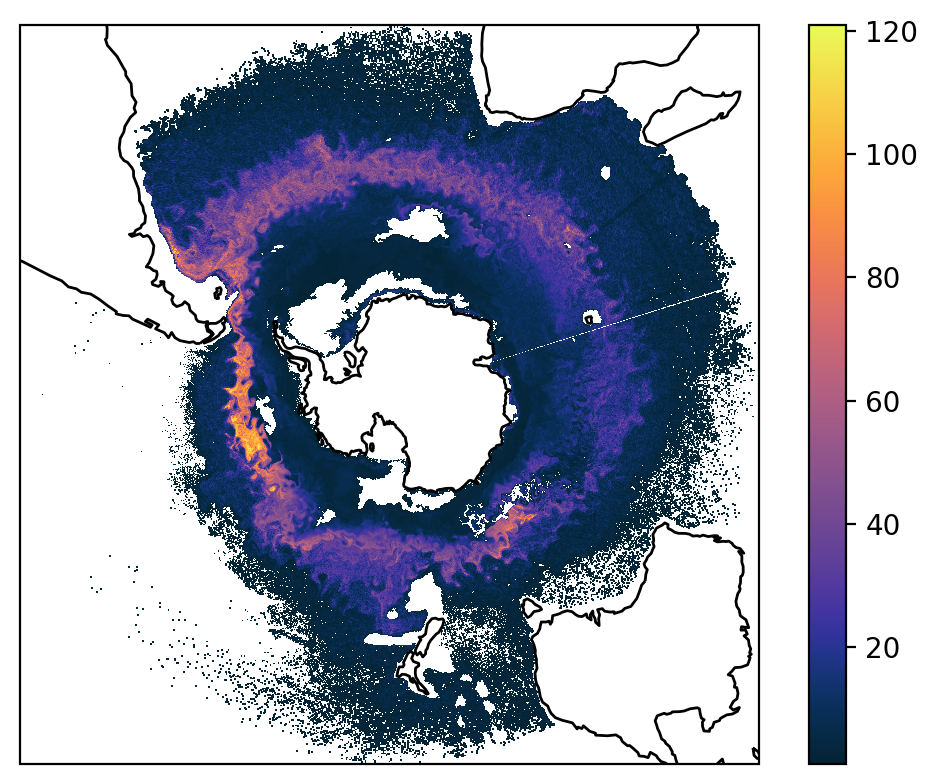

In [183]:
plot_i(ds_domain,count,'ndense',log=False)

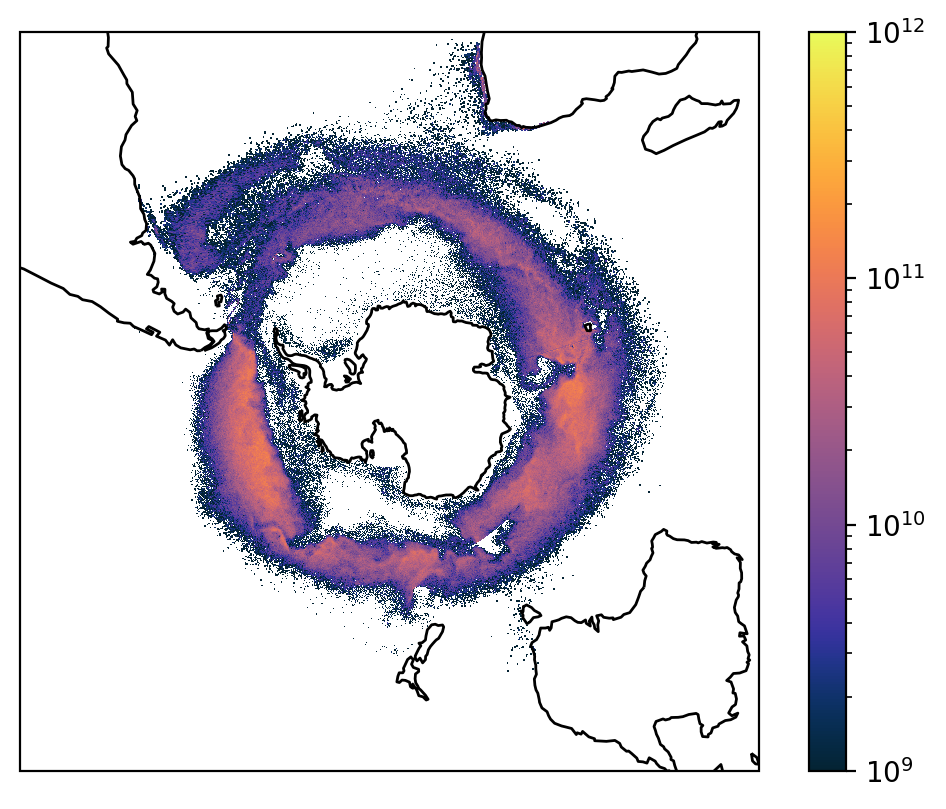

In [188]:
plot_vent(1027.1,1027.2)

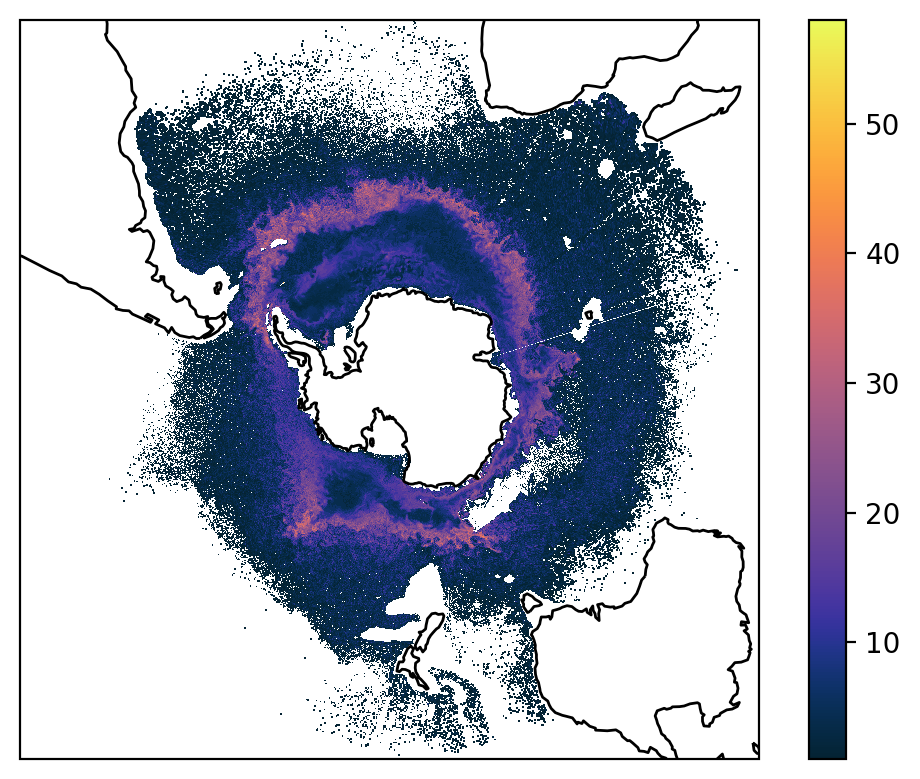

In [190]:
plot_seed(1027.4,1027.5)

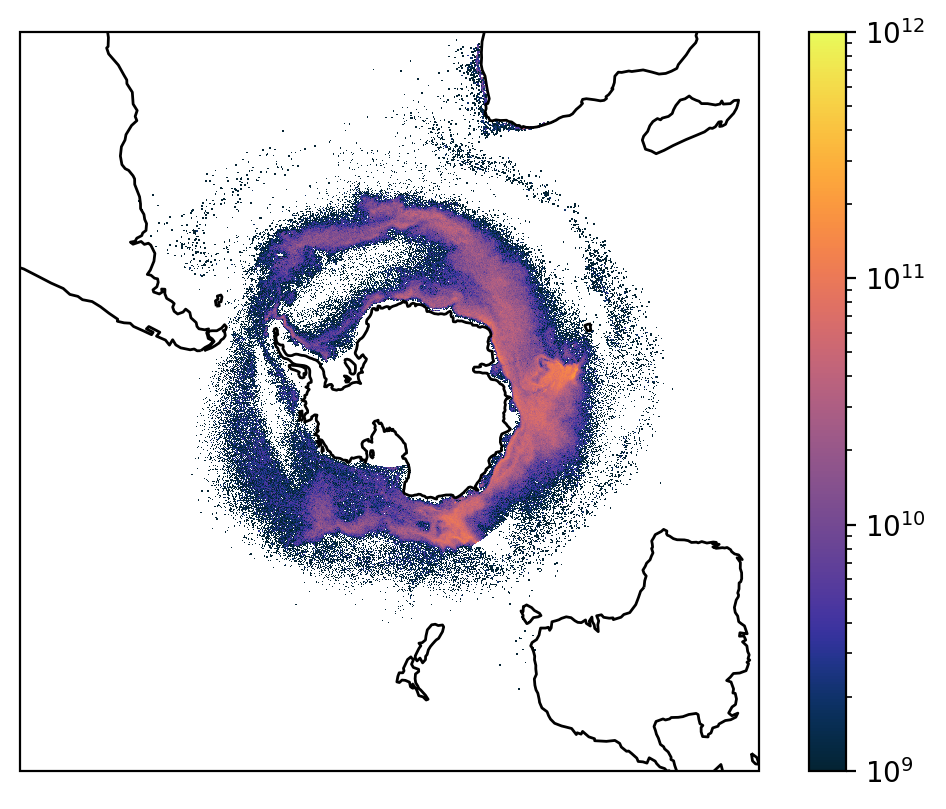

In [189]:
plot_vent(1027.4,1027.5)

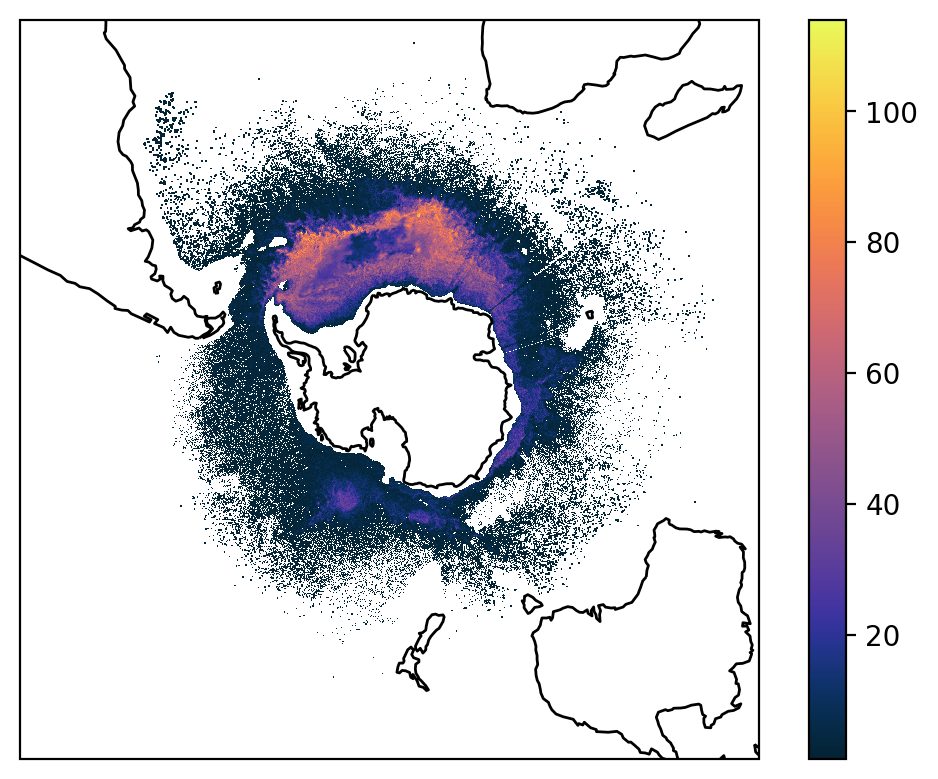

In [11]:
plot_seed(1027.7,1027.8)

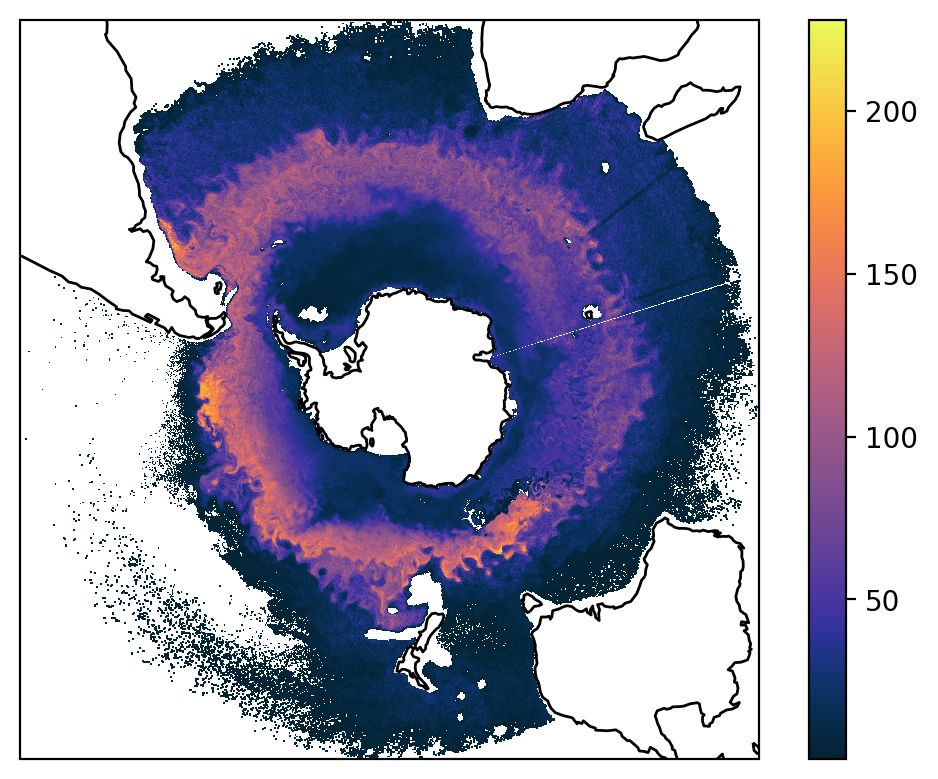

In [8]:
plot_seed(1026.9,1027.4)

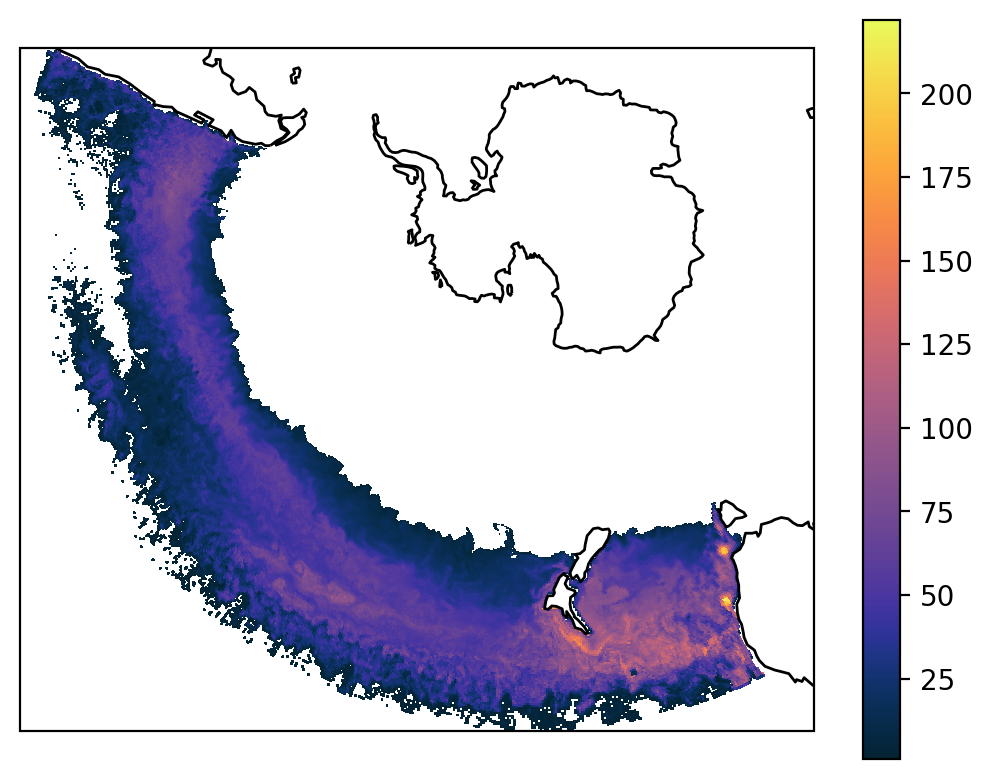

In [17]:
plot_seed(1025.1,1026.2)

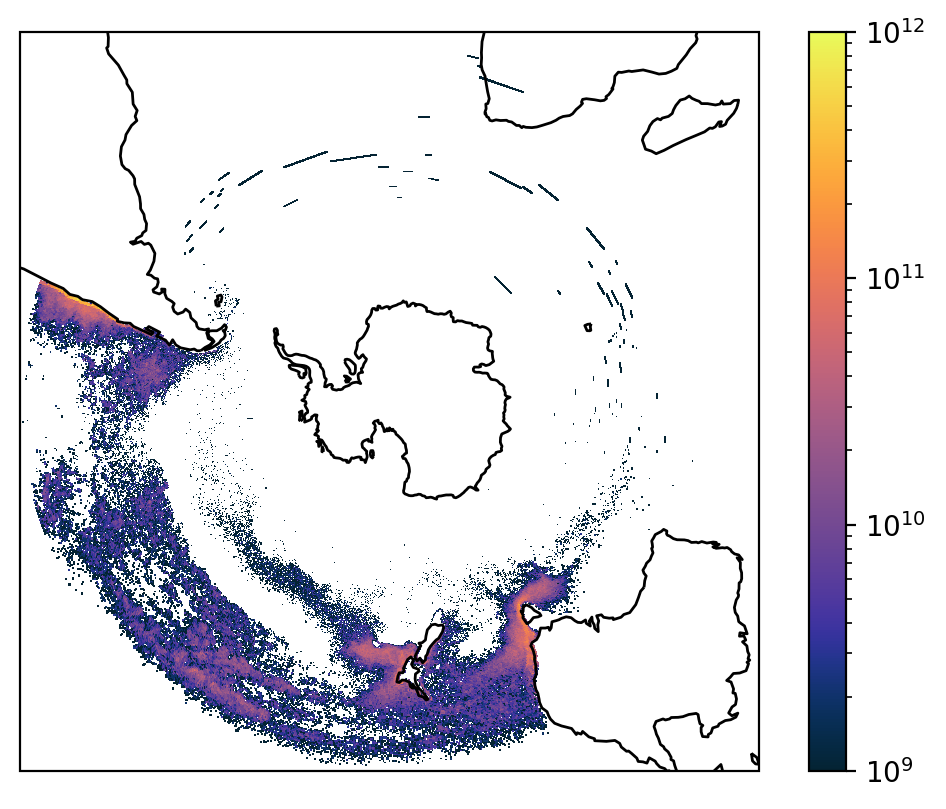

In [25]:
plot_vent(1025.1,1026.3)

In [22]:
df_densest = df_vent[(df_vent['ndense']>1025) &(df_vent['ndense']<1026.2) ][['binnedx_i','binnedy_i','ndense','z_i','year_o']]
df_densest= df_densest[df_densest['year_o']>1983]
df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
count = df_group.count().compute()



In [23]:

df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
count = df_group.mean('z_i').compute()

(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

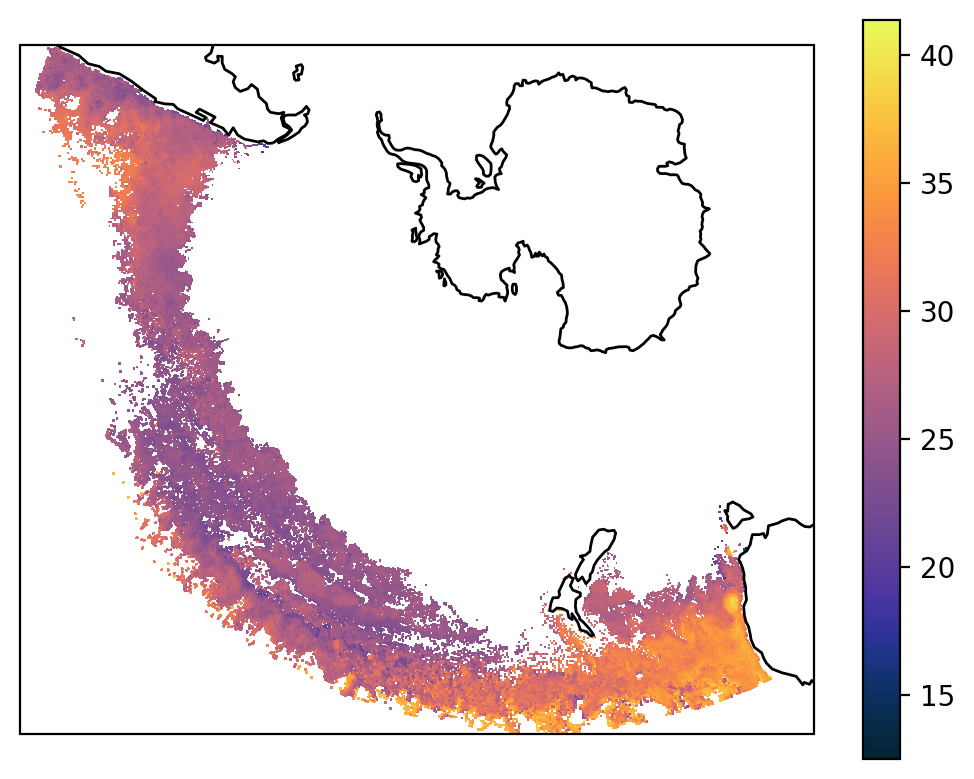

In [24]:
plot_i(ds_domain,count,'z_i',log=False)

In [53]:
df_densest = df_vent[df_vent['ndense']>1027.8]
df_group= df_densest.groupby('ndense')
dens = df_group.mean('density_o').compute()

dens = dens.reset_index()
dens=dens.sort_values('ndense')

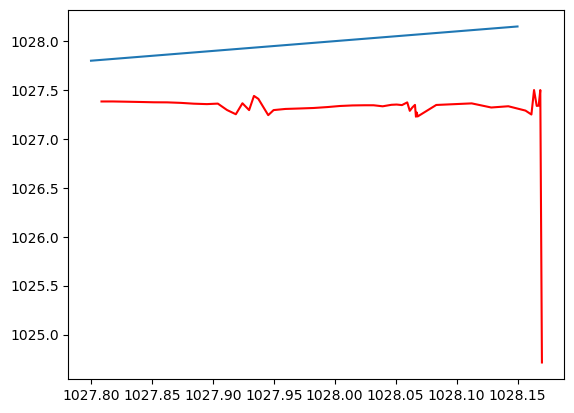

In [55]:
plt.plot(dens['ndense'],1000+dens['density_o'],c='red')
plt.plot([1027.8,1028.15],[1027.8,1028.15])

In [162]:
#############
# now look at range 1027.5 to 1027.8
df_densest = df_vent[(df_vent['ndense']<1026.9) &(df_vent['ndense']>1026.35) ][['binnedx_i','binnedy_i','ndense','year_o']]
df_densest= df_densest[df_densest['year_o']>1983]
df_group = df_densest.groupby(['binnedx_i','binnedy_i'])
count = df_group.count().compute()


(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

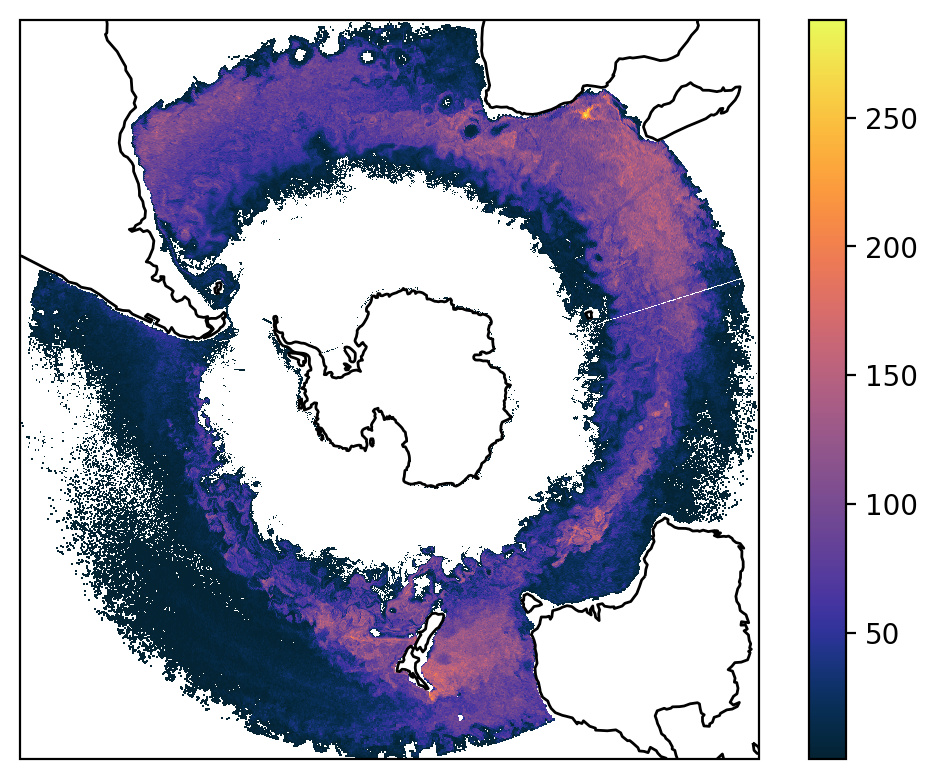

In [163]:
plot_i(ds_domain,count,'ndense',vmax=1e12,log=False)

In [171]:
df_densest = df_vent[(df_vent['ndense']<1026.9) &(df_vent['ndense']>1026.35) ][['binnedx_o','binnedy_o','subvol_o','year_o']]
df_densest= df_densest[df_densest['year_o']>1983]
df_group = df_densest.groupby(['binnedx_o','binnedy_o'])
count = df_group.sum('subvol_o').compute()


(<Figure size 1280x960 with 2 Axes>, <GeoAxes: >)

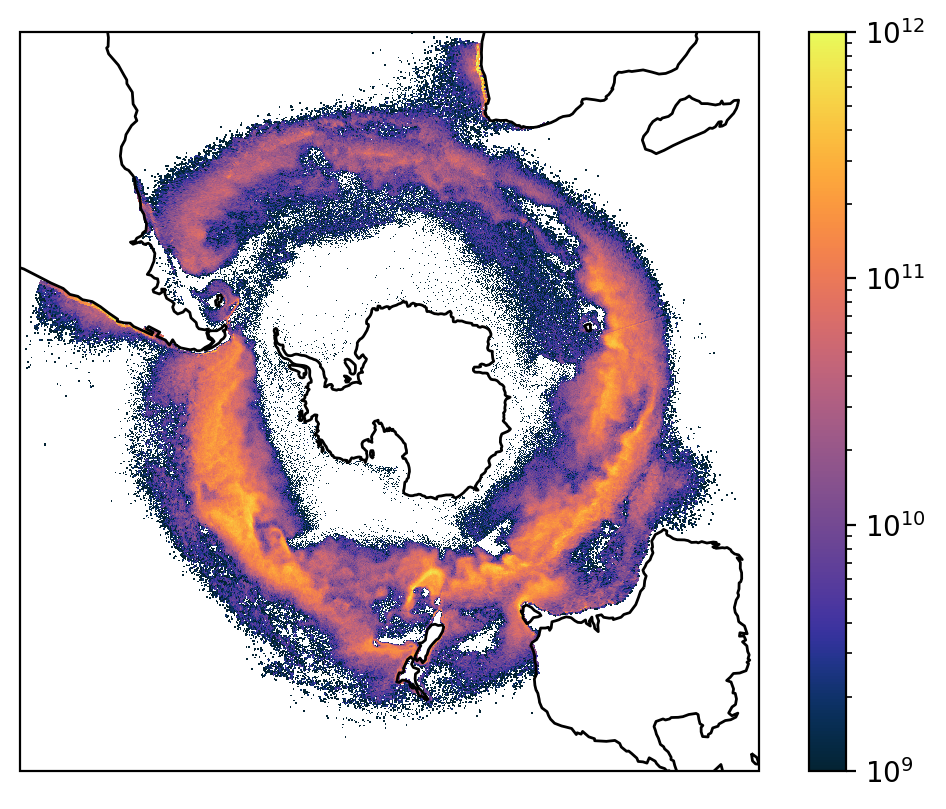

In [172]:
plot_o(ds_domain,count,'subvol_o',vmax=1e12)

In [151]:
df_densest = df_vent[(df_vent['ndense']>1025.5) &(df_vent['ndense']<1028.3)]
df_group= df_densest.groupby('ndense')
dens = df_group.mean('density_o').compute()

dens = dens.reset_index()
dens=dens.sort_values('ndense')

Text(0, 0.5, 'density out')

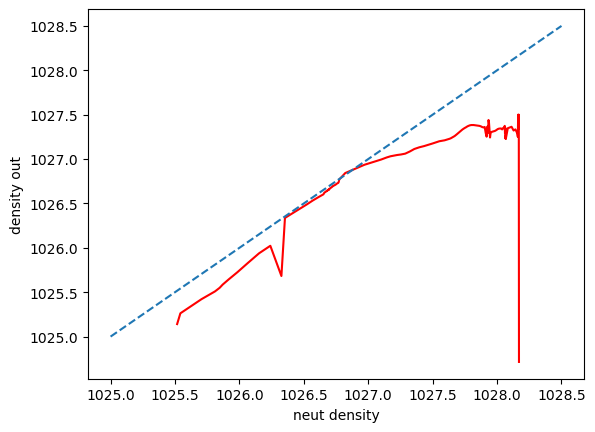

In [152]:
plt.plot(dens['ndense'],1000+dens['density_o'],c='red')
plt.plot([1025,1028.5],[1025,1028.5],ls='--')
plt.xlabel('neut density')
plt.ylabel('density out')

(1027.0, 1028.3)

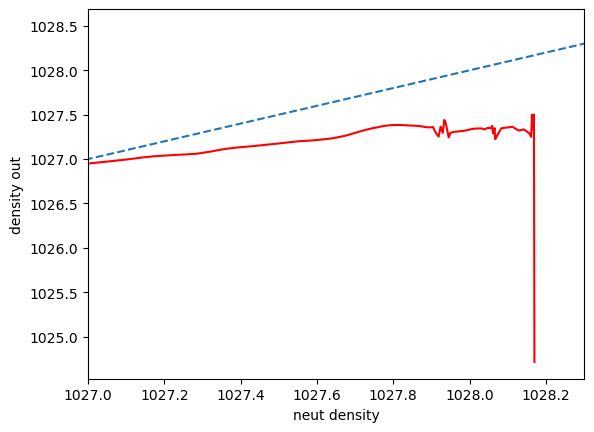

In [170]:
plt.plot(dens['ndense'],1000+dens['density_o'],c='red')
plt.plot([1025,1028.5],[1025,1028.5],ls='--')
plt.xlabel('neut density')
plt.ylabel('density out')
plt.xlim(1027.,1028.3)

In [ ]:
### make nicer plots


In [14]:
df_densest = df_vent[(df_vent['ndense']>1025.5) &(df_vent['ndense']<1028.3)]
df_group= df_densest.groupby('ndense')
dens = df_group.mean('density_o').compute()

dens = dens.reset_index()
dens=dens.sort_values('ndense')

mins = df_group.min('density_o').compute()
mins=mins.sort_values('ndense')
mins = mins.reset_index()

maxs = df_group.max('density_o').compute()
maxs=maxs.sort_values('ndense')
maxs = maxs.reset_index()

NameError: name 'yr_group' is not defined

In [15]:
maxs = df_group.max('density_o').compute()
maxs=maxs.sort_values('ndense')
maxs = maxs.reset_index()

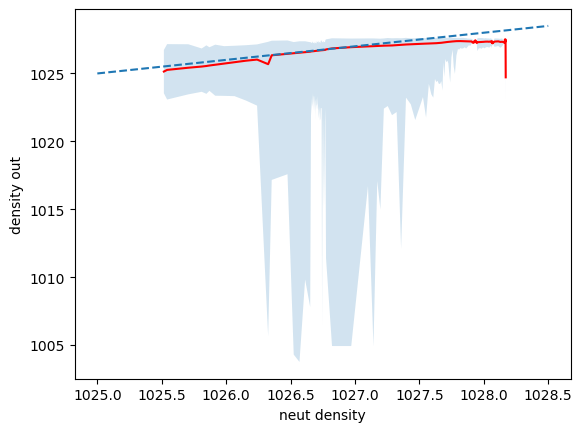

In [16]:
plt.plot(dens['ndense'],1000+dens['density_o'],c='red')
plt.plot([1025,1028.5],[1025,1028.5],ls='--')
plt.xlabel('neut density')
plt.ylabel('density out')
plt.fill_between(maxs.ndense,1000+mins.density_o,1000+maxs.density_o, alpha=0.2)

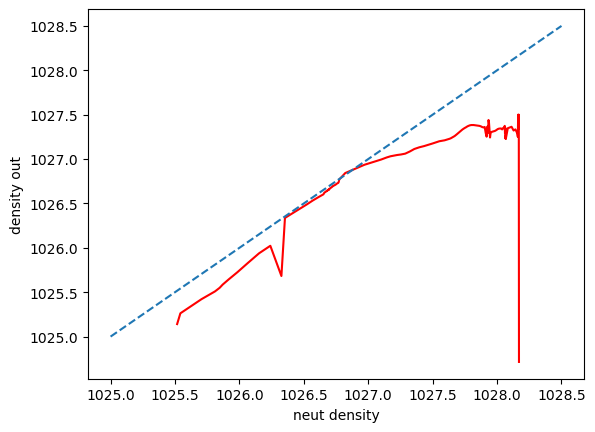

In [17]:
plt.plot(dens['ndense'],1000+dens['density_o'],c='red')
plt.plot([1025,1028.5],[1025,1028.5],ls='--')
plt.xlabel('neut density')
plt.ylabel('density out')
plt.savefig('../fig/Density_classes/all_densities.png')

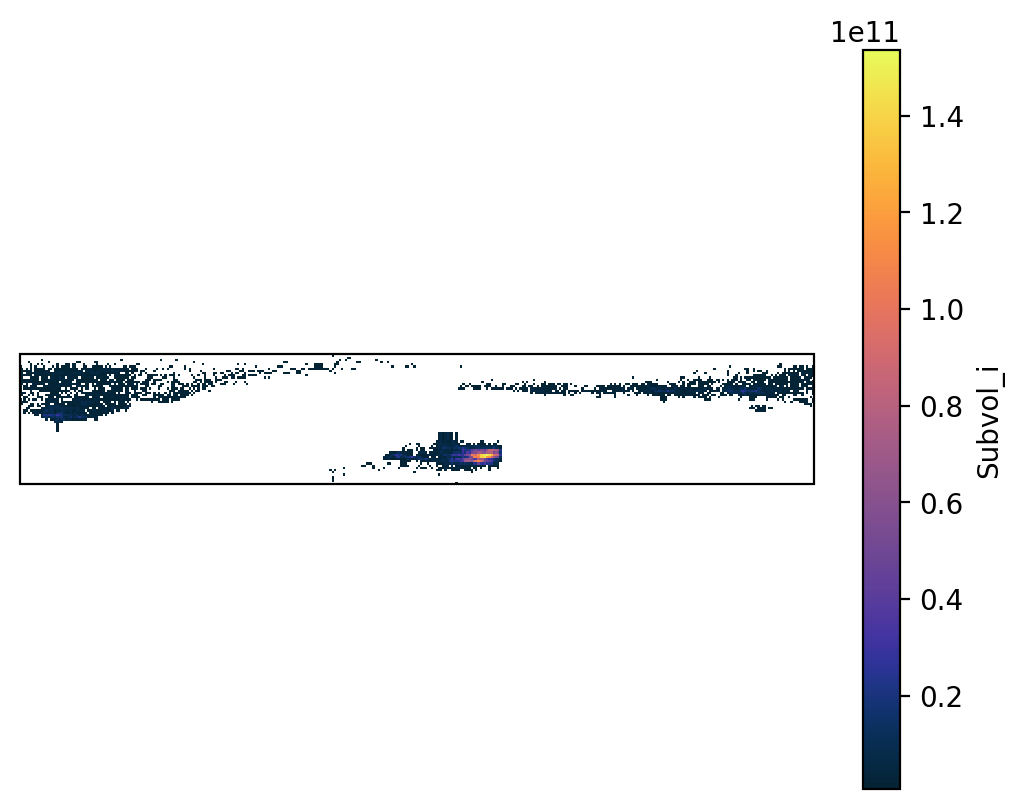

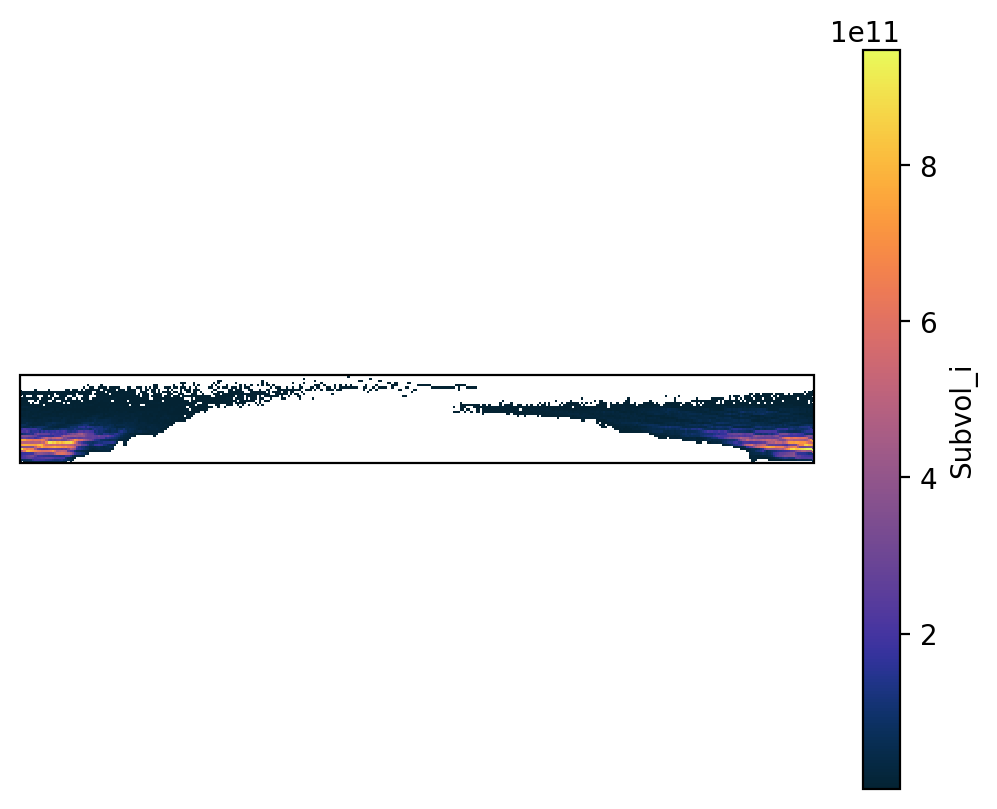

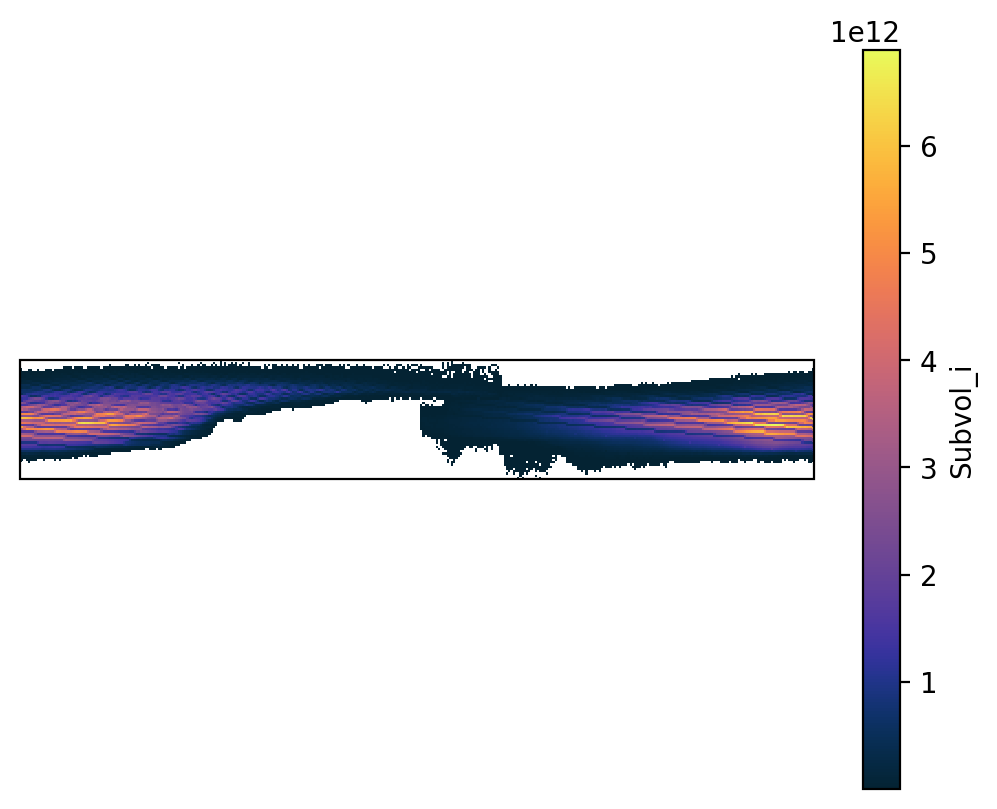

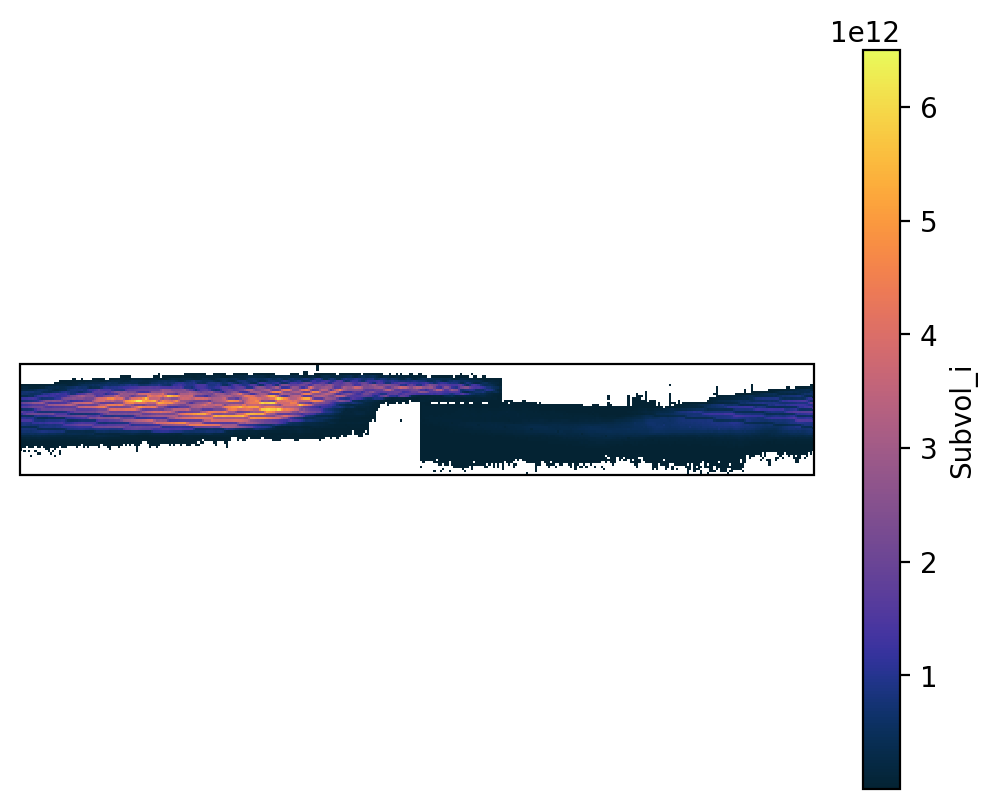

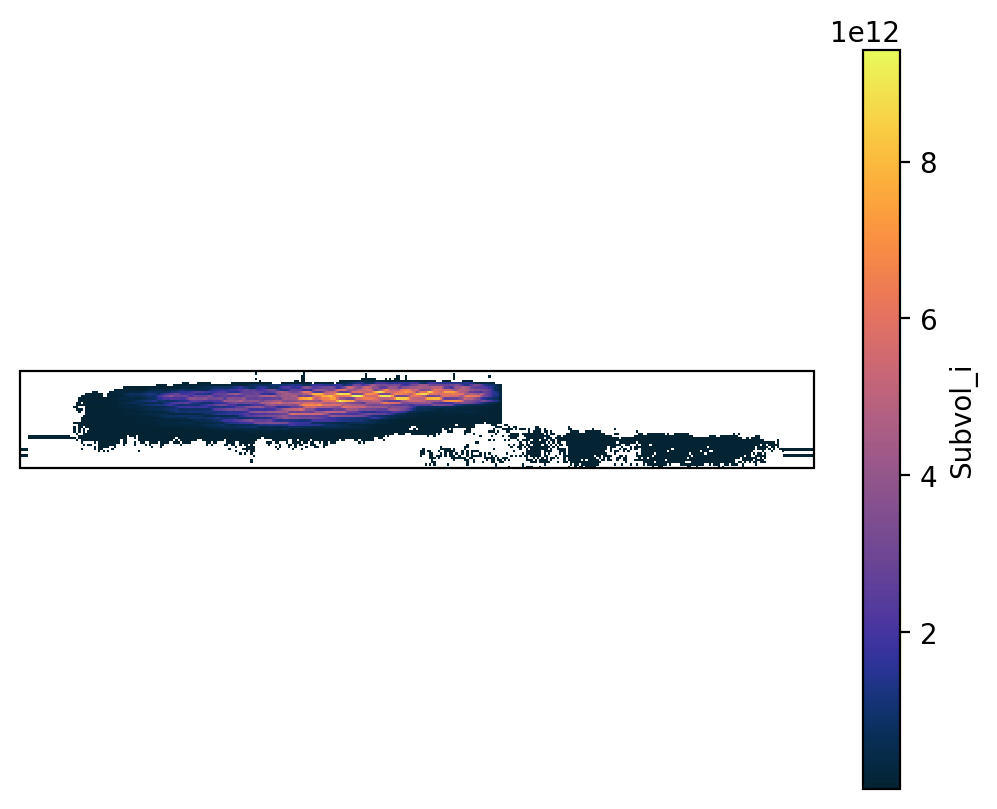

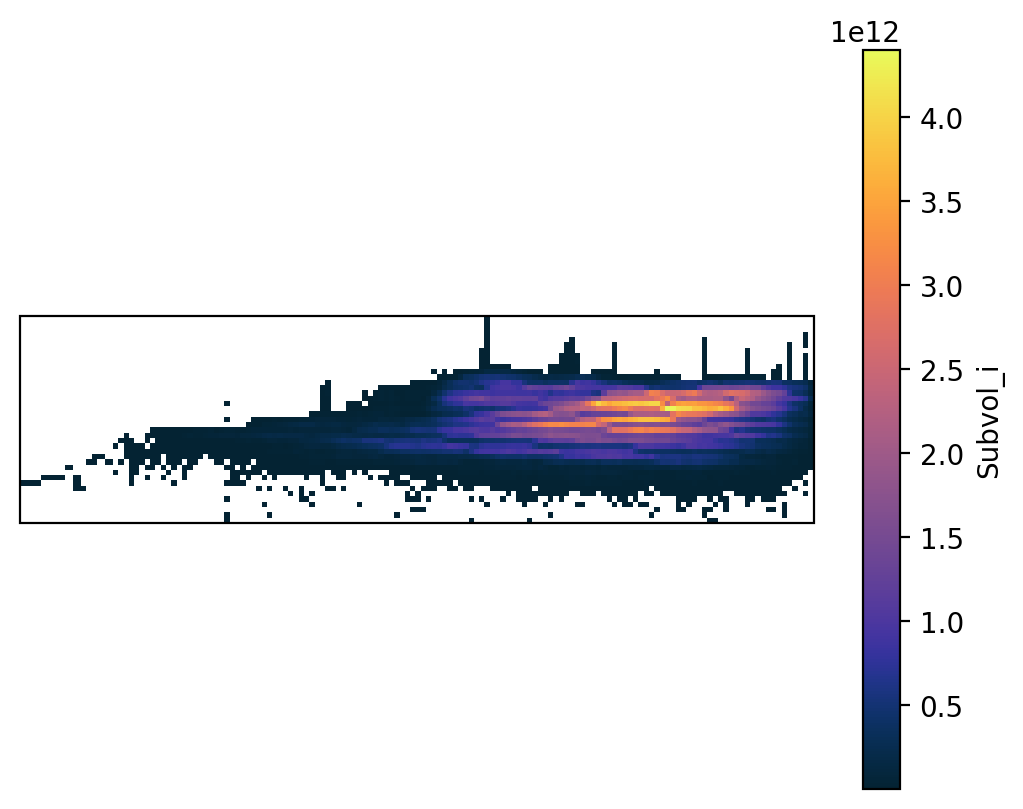

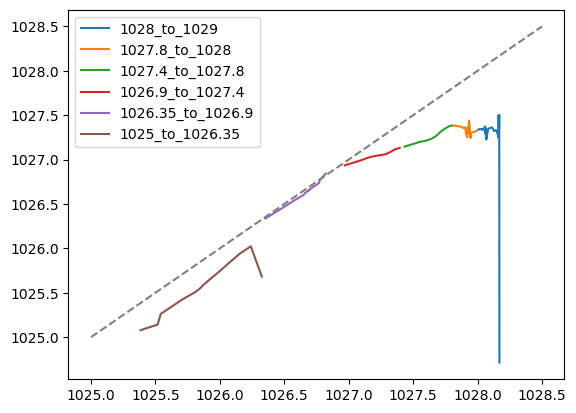

In [27]:
for clas in classes:
    df_densest = df_vent[(df_vent['ndense']>clas[0]) &(df_vent['ndense']<clas[1])]
    df_group= df_densest.groupby('ndense')
    dens = df_group.mean('density_o').compute()
    dens = dens.reset_index()
    dens=dens.sort_values('ndense')
    plt.plot(dens['ndense'],1000+dens['density_o'],label = f'{clas[0]}_to_{clas[1]}')
plt.plot([1025,1028.5],[1025,1028.5],ls='--',c='grey')
plt.legend()
plt.savefig('../fig/Density_classes/densities_classified.png')

    

In [ ]:
######
#look at the densities of the deep

In [97]:
sum_z = np.array(ds_domain.e3t_1d['gdept_1d'])
z_index = np.array(ds_domain.e3t_1d['z_c'])
cell_z = np.append(np.array(da.diff(ds_domain.e3t_1d['gdept_1d'])),0)
df_sum_in = dd.from_dict({'bin_depth_i':sum_z,'binnedz_i':z_index, 'cell_h_i':cell_z},npartitions =3)
df_merge_in = df_vent.merge(df_sum_in,on = 'binnedz_i')
df_merge_in['depth_i'] = (df_merge_in['bin_depth_i'] - da.floor(df_merge_in['bin_depth_i']))* df_merge_in['cell_h_i'] + df_merge_in['bin_depth_i']

In [99]:
df_deep = df_merge_in[df_merge_in['depth_i']>2100]


In [100]:

df_group= df_deep.groupby('ndense')
dens = df_group.mean('density_o').compute()

dens = dens.reset_index()
dens=dens.sort_values('ndense')

Text(0, 0.5, 'density out')

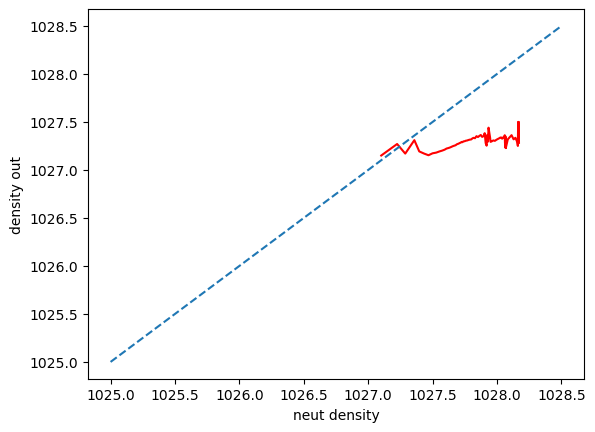

In [101]:
plt.plot(dens['ndense'],1000+dens['density_o'],c='red')
plt.plot([1025,1028.5],[1025,1028.5],ls='--')
plt.xlabel('neut density')
plt.ylabel('density out')
plt.savefig('../fig/Deep_water/densities.png')


In [106]:

yr_group  = df_deep[['year_o','z_o']].groupby('year_o') 
count = yr_group.count().compute()


count = count.sort_values('year_o')
count = count.reset_index()

<BarContainer object of 30 artists>

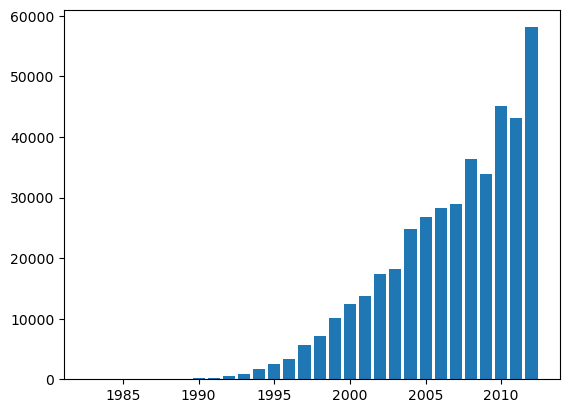

In [119]:

plt.bar(count['year_o'],count['z_o'])

In [120]:

yr_group  = df_deep[['year_o','ndense']].groupby('year_o') 
count = yr_group.mean('ndense').compute()


count = count.sort_values('year_o')
count = count.reset_index()

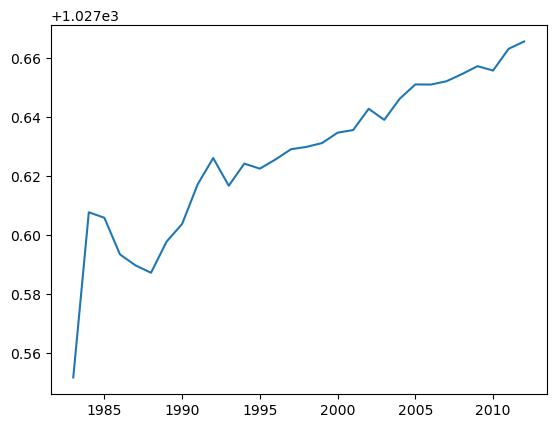

In [127]:
plt.plot(count.year_o,count.ndense)
plt.ylabel('neut dense')

In [ ]:
mins = yr_group.min('ndense').compute()
mins=mins.sort_values('year_o')
mins = mins.reset_index()

maxs = yr_group.max('ndense').compute()
maxs=maxs.sort_values('year_o')
maxs = maxs.reset_index()


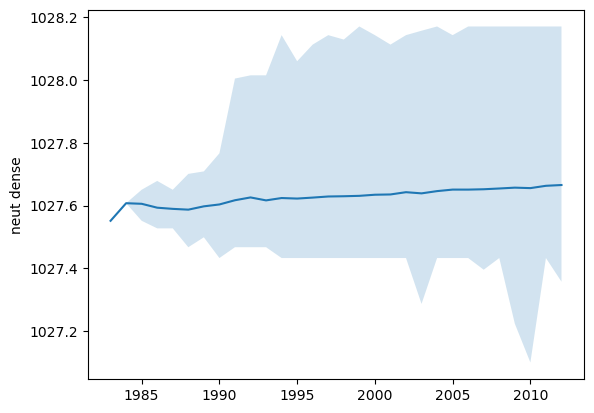

In [130]:
plt.plot(count.year_o,count.ndense)
plt.ylabel('neut dense')
plt.fill_between(maxs.year_o,mins.ndense,maxs.ndense, alpha=0.2)
